# Market & Regional Profitability Analysis

## Objective

This notebook analyses financial performance across markets and order regions within the APL Logistics dataset.

The analysis focuses on:

- Revenue and profit by market
- Profit margin by market
- Revenue and profit by order region
- Profit margin by order region
- Loss-making markets and regions
- High-revenue / low-margin markets and regions
- Discount exposure by market and region
- Geographic concentration of financial performance

The objective is to identify geographic areas with strong financial contribution and areas requiring further profitability investigation.

All relationships are interpreted descriptively and do not imply causation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load processed dataset

DATA_PATH = "../data/processed/apl_logistics_eda.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (180519, 42)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Profitability Status,Transaction Profit Margin
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,Profitable,0.338004
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,167.96,48.71,Central America,CortÃ©s,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,Profitable,0.290010
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,181.99,87.36,Central America,CortÃ©s,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,Profitable,0.480026
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,Loss-making,-0.238025
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,Profitable,0.250000


In [4]:
# Validate geographic fields

geographic_columns = [
    "Market",
    "Order Region",
    "Order Country",
    "Customer Country",
    "Sales",
    "Order Profit Per Order"
]

df[geographic_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Market                  180519 non-null  str    
 1   Order Region            180519 non-null  str    
 2   Order Country           180519 non-null  str    
 3   Customer Country        180519 non-null  str    
 4   Sales                   180519 non-null  float64
 5   Order Profit Per Order  180519 non-null  float64
dtypes: float64(2), str(4)
memory usage: 8.3 MB


In [5]:
# Check missing geographic values

df[[
    "Market",
    "Order Region",
    "Order Country",
]].isna().sum()

Market           0
Order Region     0
Order Country    0
dtype: int64

In [6]:
# Market overview

print("Number of markets:", df["Market"].nunique())

print("\nMarkets:")
print(
    df["Market"]
    .value_counts()
)

Number of markets: 5

Markets:
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


In [7]:
# Market profitability aggregation

market_profitability = (
    df.groupby("Market")
      .agg(
          Orders=("Market", "count"),
          Units=("Order Item Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Discount=("Order Item Discount", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean")
      )
      .reset_index()
)

market_profitability["Profit_Margin"] = (
    market_profitability["Profit"] /
    market_profitability["Sales"]
)

market_profitability["Sales_Share"] = (
    market_profitability["Sales"] /
    market_profitability["Sales"].sum()
)

market_profitability

,Market,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin,Sales_Share
0,Africa,11614,25603,2294452.88,252071.18,232776.37,0.101701,0.109861,0.062375
1,Europe,50252,105238,10872396.60,1169442.96,1103210.75,0.101700,0.107561,0.295568
2,LATAM,51594,112942,10277612.64,1123321.61,1041863.15,0.101576,0.109298,0.279399
3,Pacific Asia,41260,83680,8273743.58,857753.44,839493.31,0.101814,0.103672,0.224923
4,USCA,25799,56616,5066528.61,564313.78,513034.82,0.101543,0.111381,0.137735


In [8]:
# Format the market summary

market_profitability_display = market_profitability.copy()

market_profitability_display["Profit_Margin"] = (
    market_profitability_display["Profit_Margin"] * 100
).round(2)

market_profitability_display["Sales_Share"] = (
    market_profitability_display["Sales_Share"] * 100
).round(2)

market_profitability_display["Avg_Discount_Rate"] = (
    market_profitability_display["Avg_Discount_Rate"] * 100
).round(2)

market_profitability_display[
    [
        "Market",
        "Orders",
        "Units",
        "Sales",
        "Profit",
        "Discount",
        "Avg_Discount_Rate",
        "Profit_Margin",
        "Sales_Share"
    ]
].sort_values(
    "Profit",
    ascending=False
)

,Market,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin,Sales_Share
1,Europe,50252,105238,10872396.60,1169442.96,1103210.75,10.17,10.76,29.56
2,LATAM,51594,112942,10277612.64,1123321.61,1041863.15,10.16,10.93,27.94
3,Pacific Asia,41260,83680,8273743.58,857753.44,839493.31,10.18,10.37,22.49
4,USCA,25799,56616,5066528.61,564313.78,513034.82,10.15,11.14,13.77
0,Africa,11614,25603,2294452.88,252071.18,232776.37,10.17,10.99,6.24


In [9]:
# Market profitability ranking

market_profitability[
    [
        "Market",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Share"
    ]
].sort_values(
    "Profit",
    ascending=False
)

,Market,Sales,Profit,Profit_Margin,Sales_Share
1,Europe,10872396.60,1169442.96,0.107561,0.295568
2,LATAM,10277612.64,1123321.61,0.109298,0.279399
3,Pacific Asia,8273743.58,857753.44,0.103672,0.224923
4,USCA,5066528.61,564313.78,0.111381,0.137735
0,Africa,2294452.88,252071.18,0.109861,0.062375


In [10]:
# Market profit margin

market_profitability[
    [
        "Market",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
].sort_values(
    "Profit_Margin",
    ascending=False
)

,Market,Sales,Profit,Profit_Margin
4,USCA,5066528.61,564313.78,0.111381
0,Africa,2294452.88,252071.18,0.109861
2,LATAM,10277612.64,1123321.61,0.109298
1,Europe,10872396.60,1169442.96,0.107561
3,Pacific Asia,8273743.58,857753.44,0.103672


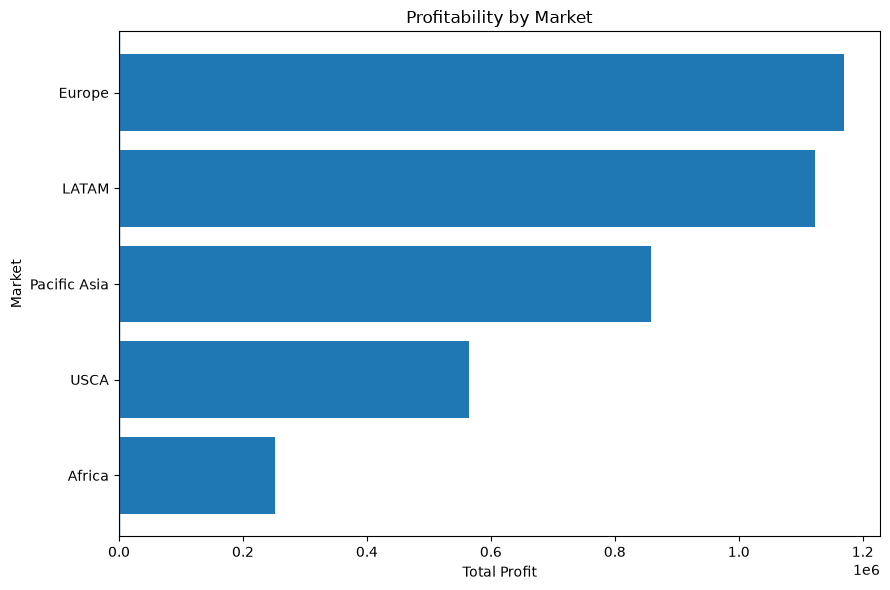

In [12]:
# Market profitability chart

plt.figure(figsize=(9, 6))

market_plot = market_profitability.sort_values("Profit")

plt.barh(
    market_plot["Market"],
    market_plot["Profit"]
)

plt.axvline(0, linewidth=1)

plt.title("Profitability by Market")
plt.xlabel("Total Profit")
plt.ylabel("Market")

plt.tight_layout()
plt.show()

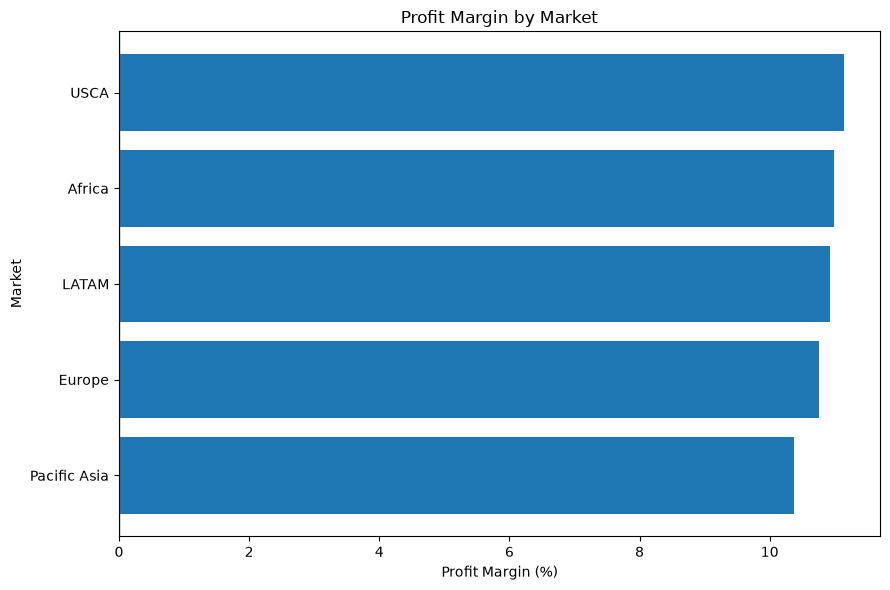

In [13]:
# Market profit margin chart

plt.figure(figsize=(9, 6))

market_margin_plot = market_profitability.sort_values("Profit_Margin")

plt.barh(
    market_margin_plot["Market"],
    market_margin_plot["Profit_Margin"] * 100
)

plt.axvline(0, linewidth=1)

plt.title("Profit Margin by Market")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Market")

plt.tight_layout()
plt.show()

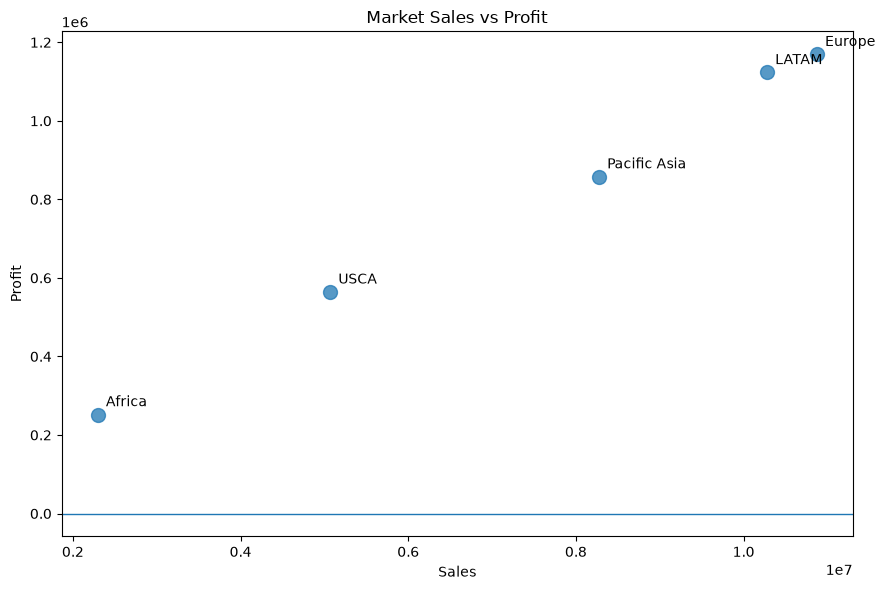

In [14]:
# Market sales vs profit

plt.figure(figsize=(9, 6))

plt.scatter(
    market_profitability["Sales"],
    market_profitability["Profit"],
    s=100,
    alpha=0.75
)

for _, row in market_profitability.iterrows():
    plt.annotate(
        row["Market"],
        (row["Sales"], row["Profit"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)

plt.title("Market Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [15]:
# High revenue / low margin markets

market_sales_median = market_profitability["Sales"].median()
market_margin_median = market_profitability["Profit_Margin"].median()

high_revenue_low_margin_markets = market_profitability[
    (market_profitability["Sales"] >= market_sales_median) &
    (market_profitability["Profit_Margin"] < market_margin_median)
].copy()

print(
    f"High-revenue / low-margin markets: "
    f"{len(high_revenue_low_margin_markets)}"
)

high_revenue_low_margin_markets[
    [
        "Market",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Share",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Sales",
    ascending=False
)

High-revenue / low-margin markets: 2


,Market,Sales,Profit,Profit_Margin,Sales_Share,Discount,Avg_Discount_Rate
1,Europe,10872396.60,1169442.96,0.107561,0.295568,1103210.75,0.101700
3,Pacific Asia,8273743.58,857753.44,0.103672,0.224923,839493.31,0.101814


In [16]:
# Order region profitability

region_profitability = (
    df.groupby("Order Region")
      .agg(
          Orders=("Order Region", "count"),
          Units=("Order Item Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Discount=("Order Item Discount", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean")
      )
      .reset_index()
)

region_profitability["Profit_Margin"] = (
    region_profitability["Profit"] /
    region_profitability["Sales"]
)

region_profitability["Sales_Share"] = (
    region_profitability["Sales"] /
    region_profitability["Sales"].sum()
)

print("Number of order regions:", len(region_profitability))

region_profitability

Number of order regions: 23


,Order Region,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin,Sales_Share
0,Canada,959,2183,186861.04,23900.71,18603.82,0.101627,0.127906,0.005080
1,Caribbean,8318,18204,1651019.30,171825.64,169352.55,0.102463,0.104072,0.044883
2,Central Africa,1677,3700,327263.01,33447.27,34350.95,0.104663,0.102203,0.008897
3,Central America,28341,62091,5665711.99,616341.57,571869.41,0.101305,0.108784,0.154023
4,Central Asia,553,1214,109839.93,13045.28,11886.36,0.105787,0.118766,0.002986
5,East Africa,1852,4048,376234.89,43167.73,38181.02,0.101722,0.114736,0.010228
6,East of USA,6915,15108,1371111.96,156263.30,139158.45,0.101524,0.113968,0.037274
7,Eastern Asia,7280,14359,1486401.31,147368.01,152090.21,0.102032,0.099144,0.040408
8,Eastern Europe,3920,8806,774266.55,79717.05,77960.36,0.100704,0.102958,0.021049
9,North Africa,3232,7155,634752.21,64599.86,62510.96,0.099805,0.101772,0.017256


In [17]:
# Format regional results

region_profitability_display = region_profitability.copy()

region_profitability_display["Profit_Margin"] = (
    region_profitability_display["Profit_Margin"] * 100
).round(2)

region_profitability_display["Sales_Share"] = (
    region_profitability_display["Sales_Share"] * 100
).round(2)

region_profitability_display["Avg_Discount_Rate"] = (
    region_profitability_display["Avg_Discount_Rate"] * 100
).round(2)

region_profitability_display[
    [
        "Order Region",
        "Orders",
        "Units",
        "Sales",
        "Profit",
        "Discount",
        "Avg_Discount_Rate",
        "Profit_Margin",
        "Sales_Share"
    ]
].sort_values(
    "Profit",
    ascending=False
)

,Order Region,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin,Sales_Share
22,Western Europe,27109,56504,5894380.66,625446.08,598384.31,10.14,10.61,16.02
3,Central America,28341,62091,5665711.99,616341.57,571869.41,10.13,10.88,15.40
12,South America,14935,32647,2960881.35,335154.40,300641.19,10.16,11.32,8.05
10,Northern Europe,9792,20402,2155830.61,233450.60,216470.73,10.20,10.83,5.86
17,Southern Europe,9431,19526,2047918.78,230829.23,210395.35,10.26,11.27,5.57
15,Southeast Asia,9539,18835,1932495.53,211342.82,193945.36,10.15,10.94,5.25
11,Oceania,10148,20430,2016654.16,201478.02,206660.62,10.24,9.99,5.48
1,Caribbean,8318,18204,1651019.30,171825.64,169352.55,10.25,10.41,4.49
13,South Asia,7731,15624,1553680.89,165703.90,156318.69,10.06,10.67,4.22
21,West of USA,7993,17547,1571415.93,164940.66,159164.32,10.11,10.50,4.27


In [18]:
# Top regions by profit

region_profitability[
    [
        "Order Region",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Share"
    ]
].sort_values(
    "Profit",
    ascending=False
).head(15)

,Order Region,Sales,Profit,Profit_Margin,Sales_Share
22,Western Europe,5894380.66,625446.08,0.106109,0.160240
3,Central America,5665711.99,616341.57,0.108784,0.154023
12,South America,2960881.35,335154.40,0.113194,0.080492
10,Northern Europe,2155830.61,233450.60,0.108288,0.058607
17,Southern Europe,2047918.78,230829.23,0.112714,0.055673
15,Southeast Asia,1932495.53,211342.82,0.109363,0.052535
11,Oceania,2016654.16,201478.02,0.099907,0.054823
1,Caribbean,1651019.30,171825.64,0.104072,0.044883
13,South Asia,1553680.89,165703.90,0.106652,0.042237
21,West of USA,1571415.93,164940.66,0.104963,0.042719


In [19]:
# Loss making regions

loss_making_regions = region_profitability[
    region_profitability["Profit"] < 0
].copy()

print(
    f"Loss-making regions: {len(loss_making_regions)}"
)

loss_making_regions[
    [
        "Order Region",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount"
    ]
].sort_values(
    "Profit"
)

Loss-making regions: 0


,Order Region,Sales,Profit,Profit_Margin,Discount


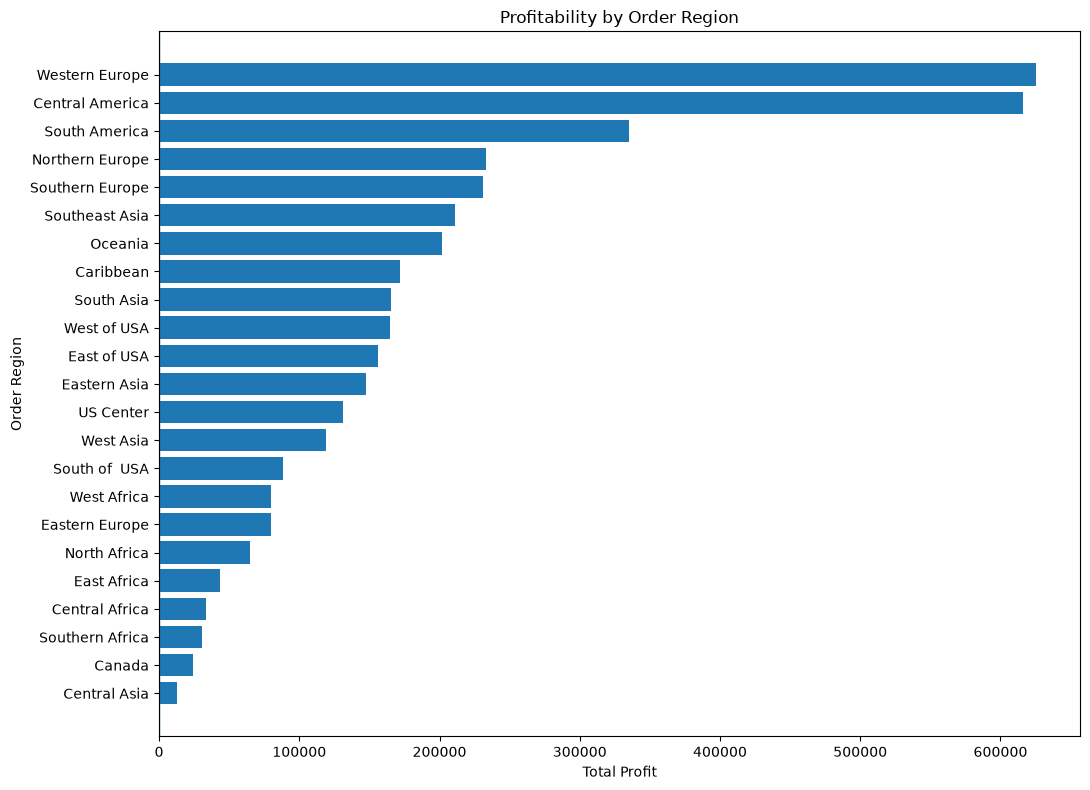

In [20]:
# Regional profitability chart

plt.figure(figsize=(11, 8))

region_plot = region_profitability.sort_values("Profit")

plt.barh(
    region_plot["Order Region"],
    region_plot["Profit"]
)

plt.axvline(0, linewidth=1)

plt.title("Profitability by Order Region")
plt.xlabel("Total Profit")
plt.ylabel("Order Region")

plt.tight_layout()
plt.show()

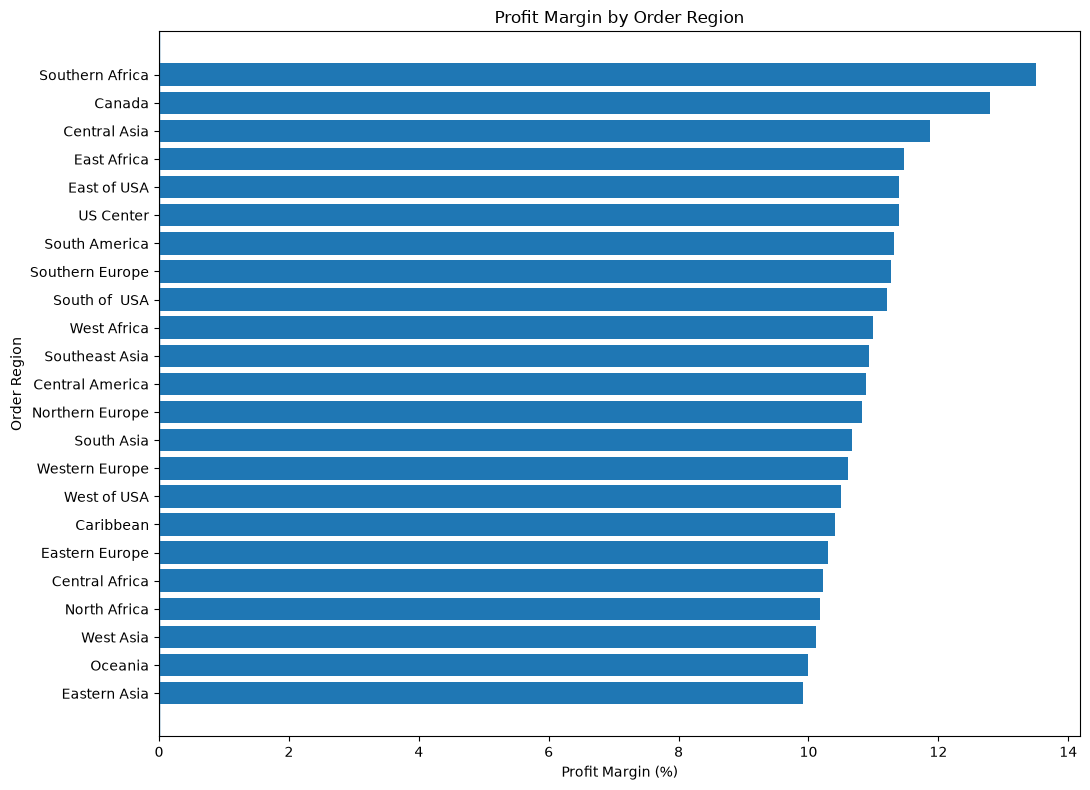

In [21]:
# Regional profit margin

plt.figure(figsize=(11, 8))

region_margin_plot = region_profitability.sort_values("Profit_Margin")

plt.barh(
    region_margin_plot["Order Region"],
    region_margin_plot["Profit_Margin"] * 100
)

plt.axvline(0, linewidth=1)

plt.title("Profit Margin by Order Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Order Region")

plt.tight_layout()
plt.show()

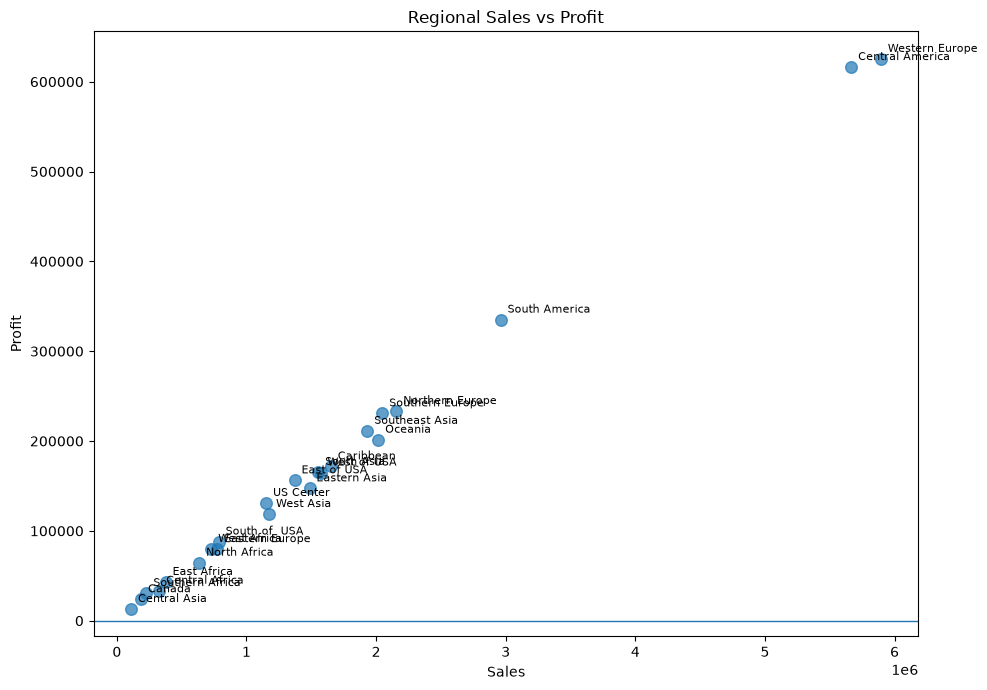

In [22]:
# Regional sales vs profit

plt.figure(figsize=(10, 7))

plt.scatter(
    region_profitability["Sales"],
    region_profitability["Profit"],
    s=70,
    alpha=0.7
)

for _, row in region_profitability.iterrows():
    plt.annotate(
        row["Order Region"],
        (row["Sales"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.axhline(0, linewidth=1)

plt.title("Regional Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [23]:
# High revenue / low margin regions

region_sales_median = region_profitability["Sales"].median()
region_margin_median = region_profitability["Profit_Margin"].median()

high_revenue_low_margin_regions = region_profitability[
    (region_profitability["Sales"] >= region_sales_median) &
    (region_profitability["Profit_Margin"] < region_margin_median)
].copy()

print(
    f"High-revenue / low-margin regions: "
    f"{len(high_revenue_low_margin_regions)}"
)

high_revenue_low_margin_regions[
    [
        "Order Region",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Share",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Sales",
    ascending=False
)

High-revenue / low-margin regions: 7


,Order Region,Sales,Profit,Profit_Margin,Sales_Share,Discount,Avg_Discount_Rate
22,Western Europe,5894380.66,625446.08,0.106109,0.160240,598384.31,0.101404
10,Northern Europe,2155830.61,233450.60,0.108288,0.058607,216470.73,0.102012
11,Oceania,2016654.16,201478.02,0.099907,0.054823,206660.62,0.102382
1,Caribbean,1651019.30,171825.64,0.104072,0.044883,169352.55,0.102463
21,West of USA,1571415.93,164940.66,0.104963,0.042719,159164.32,0.101107
13,South Asia,1553680.89,165703.90,0.106652,0.042237,156318.69,0.100582
7,Eastern Asia,1486401.31,147368.01,0.099144,0.040408,152090.21,0.102032


In [24]:
# Regional discount exposure

region_discount_analysis = region_profitability.copy()

region_discount_analysis["Discount_as_Sales"] = (
    region_discount_analysis["Discount"] /
    region_discount_analysis["Sales"]
)

region_discount_analysis[
    [
        "Order Region",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate",
        "Discount_as_Sales"
    ]
].sort_values(
    "Discount",
    ascending=False
).head(15)

,Order Region,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate,Discount_as_Sales
22,Western Europe,5894380.66,625446.08,0.106109,598384.31,0.101404,0.101518
3,Central America,5665711.99,616341.57,0.108784,571869.41,0.101305,0.100935
12,South America,2960881.35,335154.40,0.113194,300641.19,0.101594,0.101538
10,Northern Europe,2155830.61,233450.60,0.108288,216470.73,0.102012,0.100412
17,Southern Europe,2047918.78,230829.23,0.112714,210395.35,0.102641,0.102736
11,Oceania,2016654.16,201478.02,0.099907,206660.62,0.102382,0.102477
15,Southeast Asia,1932495.53,211342.82,0.109363,193945.36,0.101524,0.100360
1,Caribbean,1651019.30,171825.64,0.104072,169352.55,0.102463,0.102575
21,West of USA,1571415.93,164940.66,0.104963,159164.32,0.101107,0.101287
13,South Asia,1553680.89,165703.90,0.106652,156318.69,0.100582,0.100612


In [25]:
# Save market and regional analysis

market_profitability.to_csv(
    "../data/processed/market_profitability.csv",
    index=False
)

region_profitability.to_csv(
    "../data/processed/region_profitability.csv",
    index=False
)

high_revenue_low_margin_markets.to_csv(
    "../data/processed/high_revenue_low_margin_markets.csv",
    index=False
)

high_revenue_low_margin_regions.to_csv(
    "../data/processed/high_revenue_low_margin_regions.csv",
    index=False
)

print("Market and regional analysis outputs saved successfully.")

Market and regional analysis outputs saved successfully.
